In [ ]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np

from land_cover.load import plot_dir, loadGLAKES_GSWL, bawld_join_gswl_abz_filtered_pth, loadBAWLD

%load_ext autoreload
%autoreload 2

In [2]:
gdf = loadGLAKES_GSWL(filter_matches=False, region="na_abz", force_reload=True)

In [3]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1549717 entries, 6 to 1878283
Data columns (total 74 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Lake_id             1549717 non-null  int64   
 1   OBJECTID            1549717 non-null  float64 
 2   Area_bound          1549717 non-null  float64 
 3   Area_PW             1549281 non-null  float64 
 4   Continent_left      1549717 non-null  object  
 5   Lat                 1549717 non-null  float64 
 6   Lon                 1549717 non-null  float64 
 7   GFed_flag           1549717 non-null  int64   
 8   PFed_flag           1549717 non-null  int64   
 9   Endo_flag           1549717 non-null  int64   
 10  Rser_flag           1549717 non-null  int64   
 11  Shape_Leng          1549717 non-null  float64 
 12  Shape_Area          1549717 non-null  float64 
 13  areaP1              331823 non-null   float64 
 14  areaP2              331823 non-null   float64 


In [4]:
gdf.head()

,Lake_id,OBJECTID,Area_bound,Area_PW,Continent_left,Lat,Lon,GFed_flag,PFed_flag,Endo_flag,...,Zmean_gswl,q_gswl,area_gswl,KG_gswl,LGM_gswl,area_km2_gswl,match_gswl,dyn_ratio_gswl,depth_ratio_gswl,geometry
6,24,24.0,6987.727526,6408.023451,North America,53.549500,-63.992625,0,1,0,...,2.026318,1.515978,69100.191994,27.0,ice,0.069100,0.0,39.505209,0.381209,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5..."
10,40,40.0,4869.707306,4491.280258,North America,66.495447,-70.561392,0,1,0,...,1.864268,1.328890,20202.284957,27.0,ice,0.020202,0.0,35.948162,0.417108,"MULTIPOLYGON (((-70.77548 66.92143, -70.77575 ..."
12,47,47.0,4445.288180,4307.917229,North America,49.823532,-88.517557,0,0,0,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-88.38025 50.2885, -88.3805 50..."
13,48,48.0,4362.538872,3844.535752,North America,54.042750,-69.254000,0,1,0,...,2.660167,1.632807,195971.295800,27.0,ice,0.195971,0.0,23.308431,0.399987,"MULTIPOLYGON (((-69.4725 54.89075, -69.4725 54..."
15,57,57.0,3542.349852,3321.742907,North America,63.113516,-101.407247,0,1,0,...,2.290605,1.200772,28367.363916,27.0,ice,0.028367,0.0,25.161287,0.357860,"MULTIPOLYGON (((-100.668 63.41525, -100.668 63..."


# Join BAWLD and aggregate over its grid cells

In [5]:
# Grid to BAWLD grid to plot prevelance rel to non-selected lakes
gdf_bawld = loadBAWLD()

In [6]:
gdf.columns

Index(['Lake_id', 'OBJECTID', 'Area_bound', 'Area_PW', 'Continent_left', 'Lat',
       'Lon', 'GFed_flag', 'PFed_flag', 'Endo_flag', 'Rser_flag', 'Shape_Leng',
       'Shape_Area', 'areaP1', 'areaP2', 'areaP3', 'NDVI8499', 'NDVI0010',
       'NDVI1121', 'area_1984_', 'area_2000_', 'area_2010_', 'LEV_p1',
       'LEV_p2', 'LEV_p3', 'LEV_p13ain', 'LEV_p13rin', 'mean_bound_dist',
       'max_bound_dist', 'Hylak_id', 'Lake_name', 'Country', 'Poly_src',
       'Lake_type', 'Grand_id', 'Lake_area', 'Shore_len', 'Shore_dev',
       'Vol_total', 'Vol_res', 'Vol_src', 'Depth_avg', 'Dis_avg', 'Res_time',
       'Elevation', 'Slope_100', 'Wshd_area', 'Pour_long', 'Pour_lat',
       'latitude', 'longitude', 'sen_slope', 'mann_kendall_trend',
       'trend_significance', 'b2_mean', 'b2_stddev', 'Dmax_est_PAVEW_m',
       'Dmax_use_m', 'dyn_ratio', 'depth_ratio', 'LEV_p13in', 'index_right',
       'id_gswl', 'Zmax_gswl', 'Zmean_gswl', 'q_gswl', 'area_gswl', 'KG_gswl',
       'LGM_gswl', 'area_km2_gs

In [8]:
# temp dataset for join
_gdf_points = gpd.GeoDataFrame(
    gdf,
    geometry=gpd.points_from_xy(gdf["Lon"], gdf["Lat"]),
    crs=gdf.crs,
).drop(columns=["index_right"]).to_crs(gdf_bawld.crs)

In [9]:
# slow version to ensure nanmean
from pandas.api.types import is_float_dtype
gdf_regridded = gpd.sjoin(gdf_bawld, _gdf_points, how="left", predicate="contains")

def my_nanmean(s):
    return np.nanmean(s)

# future numpy: just use function np.nanmean
agg_map = {
    col: (my_nanmean if is_float_dtype(gdf_regridded[col]) else "first")
    for col in gdf_regridded.columns
}
agg_map["geometry"] = "first"  # ensure geometry isn't sent to np dtypes

gdf_regridded = gdf_regridded.groupby("Cell_ID", as_index=False).agg(agg_map)

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_17872/2303879128.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(s)


Now, manually add weighted mean LEV

In [10]:
_gdf_points["Area_PWxLEV_p3"] = _gdf_points["Area_PW"] * _gdf_points["LEV_p3"]
gdf_regridded_weight_mean_groupby = gpd.sjoin(gdf_bawld, _gdf_points, how="left", predicate="contains").groupby("Cell_ID")

In [11]:
def my_nansum(s):
    return np.nansum(s)


numerator = gdf_regridded_weight_mean_groupby.Area_PWxLEV_p3.agg(my_nansum)
denominator = gdf_regridded_weight_mean_groupby.Area_PW.agg(my_nansum)
gdf_regridded["LEV_p3_weighted"] = denominator

In [12]:
gdf_regridded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23469 entries, 0 to 23468
Columns: 163 entries, Area_km2 to LEV_p3_weighted
dtypes: float64(153), geometry(1), int64(3), object(6)
memory usage: 29.2+ MB


In [13]:
gdf_regridded.head()

,Area_km2,Temp_K,LEV_MEAN_k,LEV_MIN_km,LEV_MAX_km,d_counting,est_mg_m2_,est_g_day,lake_count,LEV_MEAN_f,...,Zmean_gswl,q_gswl,area_gswl,KG_gswl,LGM_gswl,area_km2_gswl,match_gswl,dyn_ratio_gswl,depth_ratio_gswl,LEV_p3_weighted
0,6.03,279.286143,0.727184,0.255664,1.710332,1.703681,7.685994,46346.545638,7.0,0.120594,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
4,0.48,275.980649,0.034568,0.010126,0.092836,0.067926,7.028025,3373.452130,2.0,0.072017,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN


In [14]:
bawld_join_gswl_abz_filtered_pth

PosixPath('/Volumes/metis/ABOVE3/other_outputs/BAWLD_GLAKES_gswl_filtered.gpkg')

In [ ]:
# export to QGIS
# gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs).to_file(bawld_join_gswl_abz_filtered_pth)

How does my LEV estimate compare to Liu 2025?

<Axes: xlabel='LEV_MEAN_f', ylabel='LEV_p3_weighted'>

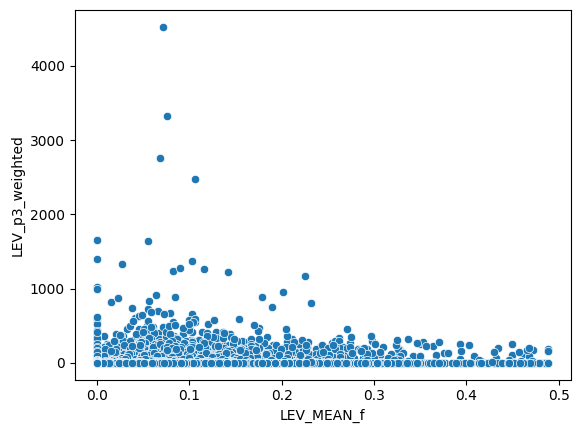

In [15]:
sns.scatterplot(gdf_regridded, x="LEV_MEAN_f", y="LEV_p3_weighted")

Error somewhere...